In [1]:
import os
import sys
import torch
import os.path
import argparse
import urllib.request

import mlflow
import mlflow.pytorch

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from data import *
from utils import *
from PIL import Image
from datetime import datetime
from sklearn.mixture import GaussianMixture as GMM
from sklearn.model_selection import train_test_split

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from MIG import compute_mig

/opt/anaconda3/envs/MT-Dev/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=700, help='Total # of samples')
parser.add_argument('--mb_size', type=int, default=64, help='Mini-batch size. See utils.py') #32, 64
parser.add_argument('--h_dim', type=int, default=48, help='Dim of latent vector') # 16, 24
parser.add_argument('--capacity', type=int, default=48, help='Capacity of network. See utils.py')

parser.add_argument('--x_fdim', type=int, default=256, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=64, help='Input y_fdim. See utils.py')
parser.add_argument('--z_fdim', type=int, default=64, help='Input z_fdim. See utils.py')

parser.add_argument('--c_accu', type=float, default=5.0, help='Weight on recons_error')
parser.add_argument('--start_iter', type=int, default=0, help='Input start_iter for training')

# Training Settings =============================
parser.add_argument('--lr', type=float, default=7e-4, help='Input learning rate for optimizer')
parser.add_argument('--max_epochs', type=int, default=0, help='Input max_epoch for cut-off')
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

h_dim = opt.h_dim

In [3]:
xtrain, xtest, ipVec_dim, nChannels = get_poem_dataloader(args=opt)

In [4]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

VOCAB = 200_000  # for o200k_base
PAD = tiktoken.get_encoding("o200k_base").eot_token

In [5]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

In [6]:
mlflow.end_run()
mlflow.set_tracking_uri("file:./mlruns")

mlflow.set_tracking_uri("file:./mlruns")
experiment_name = "GenRKM-Poem"

mlflow.set_experiment(experiment_name)
exp = mlflow.get_experiment_by_name(experiment_name)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", exp.name)
print("Experiment ID:", exp.experiment_id)

run_name = f"GenRKM-{opt.max_epochs}-{opt.h_dim}-{opt.capacity}-{ct}"

Tracking URI: file:./mlruns
Experiment: GenRKM-Poem
Experiment ID: 692294498985005034


/opt/anaconda3/envs/MT-Dev/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


In [7]:
def kPCA(X, Y, Z, eps=1e-6):
    # print(f'Sizes: X={X.size()}, Y={Y.size()}, Z={Z.size()}')
    # Kernel matrix
    a = X @ X.T + Y @ Y.T + Z @ Z.T  # (B,B)
    B = a.size(0)

    # Centering (same dtype/device as a)
    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Force symmetry (numerical)
    a = 0.5 * (a + a.T)

    # Add small jitter to diagonal for conditioning
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    # Eigen-decomposition (ascending eigenvalues)
    evals, evecs = torch.linalg.eigh(a)

    # Sort descending
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Return top components
    h = evecs[:, :h_dim]
    s = evals  # (B,)
    return h, s

In [8]:
def my_loss(output1, X, output2, Y, output3, Z):
    # Normalize all feature maps before kPCA AND projection
    o1 = F.normalize(output1.float(), dim=1)
    o2 = F.normalize(output2.float(), dim=1)
    o3 = F.normalize(output3.float(), dim=1)

    h, s = kPCA(o1, o2, o3)

    # FIX 1: Use normalized features consistently (was using raw output1/2/3)
    U = torch.mm(torch.t(o1), h)
    V = torch.mm(torch.t(o2), h)
    W = torch.mm(torch.t(o3), h)

    x_tilde, x_emb = net_text_de(torch.mm(h, torch.t(U)))
    y_tilde = net_sent_de(torch.mm(h, torch.t(V)))
    z_tilde = net_len_de(torch.mm(h, torch.t(W)))

    # RKM energy terms
    f1 = (torch.trace(torch.mm(torch.mm(o1, U), torch.t(h)))
        + torch.trace(torch.mm(torch.mm(o2, V), torch.t(h)))
        + torch.trace(torch.mm(torch.mm(o3, W), torch.t(h))))

    # FIX 2: Use only the top h_dim eigenvalues (clean scalar sum, no diag matmul)
    f2 = 0.5 * s[:h_dim].sum()

    f3 = 0.5 * (torch.trace(torch.mm(torch.t(U), U))
              + torch.trace(torch.mm(torch.t(V), V))
              + torch.trace(torch.mm(torch.t(W), W)))

    # FIX 3: Cross-entropy for text instead of cosine similarity on embeddings
    ce = nn.CrossEntropyLoss(ignore_index=PAD)
    # x_tilde: (B, 15, vocab) -> reshape to (B*15, vocab); X: (B, 15) -> (B*15,)
    f4_text = ce(x_tilde.reshape(-1, x_tilde.size(-1)), X.reshape(-1).long())

    f4_sent = nn.MSELoss()(y_tilde, Y.float())
    f4_len  = nn.MSELoss()(z_tilde, Z.float())

    f4 = f4_text + f4_sent + f4_len

    energy = -f1 + f3 + f2
    loss = energy + 0.1 * energy**2 + opt.c_accu * f4
    return loss

In [9]:
net_sent_en = NetSentEn(opt=opt).float().to(opt.device)
net_text_en = NetTextEn(d=32, vocab=VOCAB, opt=opt).float().to(opt.device)
net_len_en = NetLenEn(opt=opt).float().to(opt.device)

net_sent_de = NetSentDe(opt=opt).float().to(opt.device)
net_len_de = NetLenDe(opt=opt).float().to(opt.device)

net_text_de = NetTextDe(
    emb_layer=net_text_en.emb,   # <-- use the encoder’s embedding
    opt=opt
).float().to(opt.device)

In [10]:
params = (
    list(net_text_en.parameters()) + list(net_text_de.parameters()) +
    list(net_sent_en.parameters()) + list(net_sent_de.parameters()) +
    list(net_len_en.parameters()) + list(net_len_de.parameters())
)
# optimizer = torch.optim.Adam(params, lr=opt.lr, weight_decay=1e-5)

optimizer = torch.optim.AdamW(params, lr=opt.lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=15,
    threshold=1e-2,   # was 1e-3 — too tight for kPCA variance
    min_lr=1e-5
)

l_cost = 6  # Costs from where checkpoints will be saved
t = 1
cost = np.inf  # Initialize cost

/opt/anaconda3/envs/MT-Dev/lib/python3.13/site-packages/torch/_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


In [11]:
global_step = 0
run_id = 0

with mlflow.start_run(experiment_id=exp.experiment_id, run_name=run_name) as run:
    run_id = run.info.run_id

    mlflow.log_params({
        'N': opt.N,
        'mb_size': opt.mb_size,
        'h_dim': opt.h_dim,
        'capacity': opt.capacity,
        'x_fdim': opt.x_fdim,
        'y_fdim': opt.y_fdim,
        'z_fdim': opt.z_fdim,
        'c_accu': opt.c_accu,
        'lr': opt.lr,
        'max_epochs': opt.max_epochs,
        'device': opt.device,
        'workers': opt.workers,
        'shuffle': opt.shuffle,
    })

    while t <= opt.max_epochs:  # run epochs until convergence
        avg_loss = 0

        for i, (data_text, data_sent, data_len) in enumerate(xtrain):
            data_text = data_text.to(opt.device)
            data_sent = data_sent.to(opt.device)
            data_len = data_len.to(opt.device)
            
            output1 = net_text_en(data_text)
            output2 = net_sent_en(data_sent)
            output3 = net_len_en(data_len)

            loss = my_loss(output1, data_text, output2, data_sent, output3, data_len)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            optimizer.step()

            mlflow.log_metric('train_batch_loss', loss.item(), step=global_step)
            mlflow.log_metric('learning_rate', optimizer.param_groups[0]['lr'], step=global_step)

            global_step += 1
            avg_loss += loss.detach().cpu().numpy()
            
        cost = avg_loss / len(xtrain)
        scheduler.step(cost)

        mlflow.log_metric('train_epoch_loss', cost, step=t)
        t += 1
        
    print('Finished Training. Lowest cost: {}'.format(l_cost))

Finished Training. Lowest cost: 6


In [12]:
# # Get latest model
# if os.path.exists('cp/{}'.format(dirs.dircp)):
#     sd_mdl = torch.load('cp/{}'.format(dirs.dircp), weights_only=False)
#     net_text_en.load_state_dict(sd_mdl['net_text_en_state_dict'])
#     net_sent_en.load_state_dict(sd_mdl['net_sent_en_state_dict'])
#     net_len_en.load_state_dict(sd_mdl['net_len_en_state_dict'])
    
#     net_text_de.load_state_dict(sd_mdl['net_text_de_state_dict'])
#     net_sent_de.load_state_dict(sd_mdl['net_sent_de_state_dict'])
#     net_len_de.load_state_dict(sd_mdl['net_len_de_state_dict'])

# U, V, W, h, s = poem_final_compute(opt, net_text_en, net_sent_en, net_len_en, kPCA)

In [13]:
# # Save Model
# torch.save({'net_text_en': net_text_en,
#             'net_text_de': net_text_de,
#             'net_sent_en': net_sent_en,
#             'net_sent_de': net_sent_de,
#             'net_len_en': net_len_en,
#             'net_len_de': net_len_de,

#             'net_text_en_state_dict': net_text_en.state_dict(),
#             'net_text_de_state_dict': net_text_de.state_dict(),
#             'net_sent_en_state_dict': net_sent_en.state_dict(),
#             'net_sent_de_state_dict': net_sent_de.state_dict(),
#             'net_len_en_state_dict': net_len_en.state_dict(),
#             'net_len_de_state_dict': net_len_de.state_dict(),

#             'data_text': data_text,
#             'data_sent': data_sent,
#             'data_len': data_len,

#             'h': h, 's': s, 'U': U, 'V': V, 'W': W}, 'out/{}'.format(dirs.dirout))

In [14]:
model = torch.load('out/Final-3V.tar', weights_only=False)

U = model['U']
V = model['V']
W = model['W']
h = model['h']
s = model['s']

data_text = model['data_text']
data_sent = model['data_sent']
data_len = model['data_len']

net_text_en = model['net_text_en']
net_text_de = model['net_text_de']

net_sent_en = model['net_sent_en']
net_sent_de = model['net_sent_de']

net_len_en = model['net_len_en']
net_len_de = model['net_len_de']

## Evaluation

In [15]:
all_text, all_sent, all_len = [], [], []
all_text_en, all_sent_en, all_len_en = [], [], []
all_text_de, all_sent_de, all_len_de = [], [], []

In [16]:
txt_encoder = tiktoken.get_encoding("o200k_base")

In [17]:
with torch.no_grad():
    for data_text, data_sent, data_len in xtest:
        data_text = data_text.to(opt.device)
        data_sent = data_sent.to(opt.device)
        data_len = data_len.to(opt.device)

        text_en = net_text_en(data_text)
        sent_en = net_sent_en(data_sent)
        len_en = net_len_en(data_len)

        all_text_en.append(text_en.cpu())
        all_sent_en.append(sent_en.cpu())
        all_len_en.append(len_en.cpu())

        all_text.append(data_text)
        all_sent.append(data_sent)
        all_len.append(data_len)

In [18]:
all_text_en = torch.cat(all_text_en, dim=0)
all_sent_en = torch.cat(all_sent_en, dim=0)
all_len_en = torch.cat(all_len_en, dim=0)

all_text = torch.cat(all_text, dim=0)
all_sent = torch.cat(all_sent, dim=0)
all_len = torch.cat(all_len, dim=0)

In [19]:
with torch.no_grad():
    h_test, _ = kPCA(all_text_en, all_sent_en, all_len_en)

    U_test = all_text_en.T @ h_test
    V_test = all_sent_en.T @ h_test
    W_test = all_len_en.T @ h_test

    all_text_de, _ = net_text_de(h_test @ U_test.T)
    all_sent_de = net_sent_de(h_test @ V_test.T)
    all_len_de = net_len_de(h_test @ W_test.T)

In [27]:
all_text_de.shape

torch.Size([640, 15, 200000])

Text Results:
 > Target:
   > [  6332  35612   9861  81622     13    306   1879  37838  45030    375
 199999 199999 199999 199999 199999]
   > with pale blue berries. in these peaceful shades--<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>

 > Reconstruction:
   > [  6332  35612   9861      0    295    306   1879    261  45030 115657
   3728    885 122089  60246 122946]
   > with pale blue!ed in these a shades lyn fore's ferd dread solemn

 > Length:
   > Target: 8
   > Reconstruction: 10

Sentiment Results:


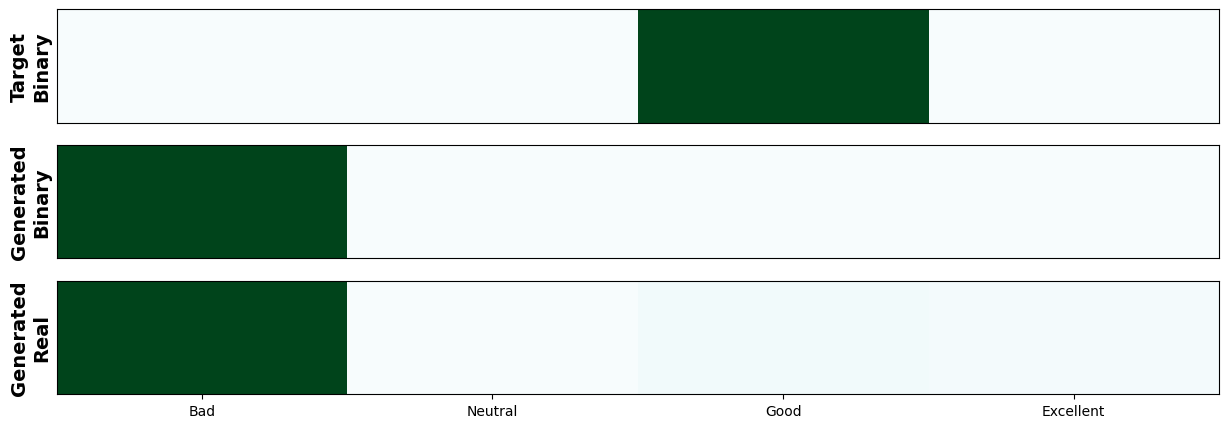

In [20]:
idx = 0

target_tokens = all_text[idx].long()
pred_tokens = all_text_de[idx].argmax(dim=-1)

print(f'Text Results:')
print(f' > Target:')
print(f'   > {target_tokens.cpu().numpy()}')
print(f'   > {txt_encoder.decode(target_tokens.cpu().numpy())}')
print()
print(f' > Reconstruction:')
print(f'   > {pred_tokens.cpu().numpy()}')
print(f'   > {txt_encoder.decode(pred_tokens.cpu().numpy())}')
print()
print(f' > Length:')
print(f'   > Target: {max(0, all_len[idx].argmax().item() - 1)}')
print(f'   > Reconstruction: {max(0, all_len_de[idx].argmax().item() - 1)}')
print()
print(f'Sentiment Results:')


sent_tgt_np = all_sent[idx].detach().cpu().numpy()
sent_rec_np = all_sent_de[idx].detach().cpu().numpy()
sent_rec_onehot = (np.arange(sent_rec_np.shape[-1]) == np.argmax(sent_rec_np)).astype(np.int64).reshape(1, -1)

fig, ax = plt.subplots(3, 1, figsize=(15, 5))

ax[0].imshow(sent_tgt_np.reshape(1, -1), cmap='BuGn', aspect='auto')
ax[0].set_yticks([]); ax[0].set_xticks([])
ax[0].set_ylabel('Target\nBinary', rotation=90, size=14, weight='bold')

ax[1].imshow(sent_rec_onehot, cmap='BuGn', aspect='auto')
ax[1].set_yticks([]); ax[1].set_xticks([])
ax[1].set_ylabel('Generated\nBinary', rotation=90, size=14, weight='bold')

ax[2].imshow(sent_rec_np.reshape(1, -1), cmap='BuGn', aspect='auto')
ax[2].set_yticks([]); ax[2].set_xticks([])
ax[2].set_xticks(np.arange(4))
ax[2].set_xticklabels(['Bad', 'Neutral', 'Good', 'Excellent'])
ax[2].set_ylabel('Generated\nReal', rotation=90, size=14, weight='bold')

plt.show()

### Loss Scores

In [21]:
recon_loss1 = nn.CrossEntropyLoss(ignore_index=PAD)
recon_loss2 = nn.MSELoss()
recon_loss3 = nn.MSELoss()

tes_text_loss = recon_loss1(all_text_de.reshape(-1, all_text_de.size(-1)), all_text.reshape(-1).long())
tes_sent_loss = recon_loss2(all_sent_de, all_sent)
tes_len_loss = recon_loss3(all_len_de, all_len)

print(f'Test Text Loss: {tes_text_loss.item():.4f}')
print(f'Test Sentence Loss: {tes_sent_loss.item():.4f}')
print(f'Test Length Loss: {tes_len_loss.item():.4f}')
print()
print(f'Overall Test Loss: {tes_text_loss.item() + tes_sent_loss.item() + tes_len_loss.item():.4f}')

Test Text Loss: 0.3390
Test Sentence Loss: 0.1227
Test Length Loss: 0.0524

Overall Test Loss: 0.5142


In [22]:
with mlflow.start_run(run_id=run_id, nested=True):
    mlflow.log_metric('test_text_loss', tes_text_loss.item())
    mlflow.log_metric('test_sent_loss', tes_sent_loss.item())
    mlflow.log_metric('test_len_loss', tes_len_loss.item())
    mlflow.log_metric('test_overall_loss', tes_text_loss.item())

## Disentanglement
### DCI

In [23]:
# Cs = []
# Zs = []

# with torch.no_grad():
#     for data_text, data_sent, data_len in loader:
#         data_sent = data_sent.to(opt.device)

#         Zs.append(data_sent.cpu().numpy())

# C = h.detach().cpu().numpy()
# Zs = np.concatenate(Zs, axis=0)

# factor_types = ['discrete'] * Zs.shape[1]

In [24]:
# res = compute_dci(C, Zs, factor_types, probe="rf")
# report_dci(res, title='Combined DCI Scores')

### IRS

In [25]:
# irs_res = compute_irs(C, Zs)

# print(f'--- IRS Scores ---')
# print(f' > Disentanglement: {round(irs_res["IRS"], 4)}')

### MIG

In [26]:
# mig_res = compute_mig(C, Zs)
# print(f'--- MIG Scores ---')
# print(f' > MIG: {round(mig_res["MIG"], 4)}')